In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.api import OLS
import numpy as np

%matplotlib inline

In [2]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# import Global Longitudinal University Enrollment Dataset (GLUED) dataset
# variable “iau_id1” identifies unique institutions
# enrollments are estimated by the variable “students5_estimated”
enrollments_df = pd.read_csv('data/enrollments.csv')
enrollments_schema_df = pd.read_csv('data/enrollments_schema.csv', sep='\t', header=None, names=['col_name', 'col_description'])

# import GDP dataset
gdp_df = pd.read_csv('data/Countries GDP 1960-2020.csv')

/var/folders/b2/02gpftds08xb3w68cklsnk3m0000gp/T/ipykernel_79272/2835669977.py:4: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  enrollments_df = pd.read_csv('data/enrollments.csv')


In [4]:
# inspect the dataset
enrollments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161560 entries, 0 to 161559
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   country                 161560 non-null  object 
 1   countrycode             159698 non-null  object 
 2   region                  159698 non-null  object 
 3   incomegroup             159691 non-null  object 
 4   iau_id                  161553 non-null  object 
 5   iau_id1                 161553 non-null  object 
 6   eng_name                161553 non-null  object 
 7   orig_name               138446 non-null  object 
 8   foundedyr               161525 non-null  float64
 9   yrclosed                460 non-null     float64
 10  private01               161525 non-null  float64
 11  coordinates             138352 non-null  object 
 12  latitude                138352 non-null  object 
 13  longitude               138352 non-null  object 
 14  phd_granting        

In [5]:
enrollments_df.describe()

,foundedyr,yrclosed,private01,phd_granting,m_granting,b_granting,divisions,total_fields,unique_fields,specialized,merger,noiau,year,students5_interpolated,students5_extrapolated,students5_estimated
count,161525.000000,460.000000,161525.000000,161525.000000,21208.000000,21208.000000,21208.000000,21208.000000,21208.000000,161525.000000,161525.000000,161525.000000,161525.000000,5.394600e+04,1.055730e+05,1.428190e+05
mean,1938.505296,2007.595652,0.431506,0.054710,0.538853,0.844634,7.011316,26.703367,22.690400,0.211812,0.109500,0.002532,1993.933075,1.142522e+04,8.890148e+03,6.804206e+03
std,84.171055,14.315523,0.495288,0.227414,0.498500,0.362262,7.173974,33.393587,23.650079,0.408594,0.312267,0.050257,20.178274,3.622171e+04,2.950551e+04,2.435944e+04
min,859.000000,1952.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1950.000000,2.000000e+00,0.000000e+00,0.000000e+00
25%,1921.000000,2004.000000,0.000000,0.000000,0.000000,1.000000,3.000000,7.000000,7.000000,0.000000,0.000000,0.000000,1980.000000,1.879250e+03,1.124000e+03,1.148000e+03
50%,1958.000000,2014.000000,0.000000,0.000000,1.000000,1.000000,5.000000,16.000000,15.000000,0.000000,0.000000,0.000000,2000.000000,5.173000e+03,3.393000e+03,2.705000e+03
75%,1983.000000,2016.000000,1.000000,0.000000,1.000000,1.000000,9.000000,34.000000,31.000000,0.000000,0.000000,0.000000,2010.000000,1.247000e+04,9.199000e+03,6.492000e+03
max,2020.000000,2022.000000,1.000000,1.000000,1.000000,1.000000,119.000000,661.000000,257.000000,1.000000,1.000000,1.000000,2020.000000,2.673333e+06,2.673333e+06,2.673333e+06


In [6]:
# inspect the schema for this dataset
enrollments_schema_df

,col_name,col_description
0,country,"Name of country. The default is the country name, merged in from the World Development Indicators. The name represents the country the institution is currently located in many country borders have changed over time and so this does not necessarily represent the name of the country when founded or historically."
1,countrycode,Three-letter code outlined by ISO 3166 alpha-3 international standard.
2,region,"Region in which the institution is currently situated, merged from the World Bank."
3,incomegroup,"Income group, merged from the World Bank."
4,iau_id,"This is a unique identifier for each university-level institution. The data comes from IAU’s World Higher Education Database, which can be found here: https://whed.net/"
5,iau_id1,"This is a unique identifier specific to our dataset, that is used to identify institutions that were once separate but later merged and today all have the same iau_id."
6,eng_name,Current name of university in English. Some of these names were translated from Google Translate and will need to be cleaned up in a future iteration.
7,orig_name,"Current name of university in Latin characters, as reported to IAU-WHED."
8,foundedyr,The year in which each respective university recognizes as the year they were founded/established.
9,yrclosed,"Year university closed, if closed and year known."


In [7]:
# inspecting data quality considering warning above (wrt latitude/longitude columns)
# appears that there is both numerical values and strings referencing google maps
enrollments_df.groupby(['latitude'])['latitude'].agg('count')

latitude
-46.413608                                                                                          10
-45.866073                                                                                          11
-43.53789                                                                                           15
-41.307779                                                                                          11
-41.301582                                                                                          12
                                                                                                    ..
 https://www.google.com/maps/search/Jos%C3%A9+Mar%C3%ADa+Vargas+University+venezuela                 8
 https://www.google.com/maps/search/University+of+Bath+united%20kingdom                             15
 https://www.google.com/maps/search/University+of+Ja%C3%A9n+spain                                    6
 https://www.google.com/maps/search/University+of+Oxford+Corpus+

In [8]:
# inspecting the first few rows indicates that they were essentially missing all data
# let's look at missingness
enrollments_df['null_val_cnt'] = enrollments_df.isnull().sum(axis=1)
enrollments_df.groupby('null_val_cnt')['country'].agg('count')

null_val_cnt
1      7026
2      3446
3     10246
4       228
5        81
6     32450
7     39417
8     40157
9      4283
10     9246
11     7583
12     5035
13     2271
14       18
16       38
20       28
24        7
Name: country, dtype: int64

In [9]:
# let's start with focusing in where data is more available for a vast majority of rows
enrollments_subset_df = enrollments_df[enrollments_df['null_val_cnt'] < 14]

In [10]:
# Check that there are not duplicate ids within a year, to confirm the shape of the data prior to aggregations
# ids are unique per year
enrollments_subset_df.groupby('year')['iau_id1'].agg({'count', 'nunique'})

,nunique,count
year,,
1950.0,4634,4634
1955.0,5149,5149
1960.0,5836,5836
1965.0,6638,6638
1970.0,7453,7453
1975.0,8276,8276
1980.0,8946,8946
1985.0,9669,9669
1990.0,10580,10580


In [11]:
# What civil or geopolitical events do you think you might be able to detect with this data set?
# Hypothesis 1) There is a change in US enrollment rate of increase when the party of the sitting president switches 
# between democrat to republican vs. republican to democrat
# Hypothesis 2) 2008 financial crisis will be indicated within this dataset

In [12]:
# create a map to the part of the sitting president for each year in this dataset
year_to_presidency_map = {1950: 'democrat',
                          1955: 'republican',
                          1960: 'republican',
                          1965: 'democrat',
                          1970: 'republican',
                          1975: 'republican',
                          1980: 'democrat',
                          1985: 'republican',
                          1990: 'republican',
                          1995: 'democrat',
                          2000: 'republican',
                          2005: 'republican',
                          2010: 'democrat',
                          2015: 'democrat',
                          2020: 'republican'
                         }

In [13]:
# subset to US data
enrollments_us_df = enrollments_subset_df[enrollments_subset_df['country'] == 'united states']
enrollments_us_df['presidential_party'] = enrollments_us_df['year'].map(year_to_presidency_map)

/var/folders/b2/02gpftds08xb3w68cklsnk3m0000gp/T/ipykernel_79272/840431416.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enrollments_us_df['presidential_party'] = enrollments_us_df['year'].map(year_to_presidency_map)


In [14]:
# aggregate enrollments by year
enrollments_us_total = enrollments_us_df.groupby(['year'])['students5_estimated'].agg(['sum']).reset_index()

In [15]:
# aggregate enrollments by year (w/ party information)
enrollments_us_total_by_party = enrollments_us_df.groupby(['year', 'presidential_party'])['students5_estimated'].agg(['sum']).reset_index()

In [16]:
# function to map party change to a string
def party_change(row):
    if row['presidential_party'] == row['prior_party']:
        # if prior and current year the same party
        return 'same'
    elif row['presidential_party'] == 'republican' and row['prior_party'] == 'democrat':
        # if prior year democrat and current republican
        return 'd2r'
    elif row['presidential_party'] == 'democrat' and row['prior_party'] == 'republican':
        # if prior year republican and current democrat
        return 'r2d'
    else:
        return None

enrollments_us_total_by_party['perc_change'] = enrollments_us_total_by_party['sum'].pct_change()
enrollments_us_total_by_party['prior_party'] = enrollments_us_total_by_party['presidential_party'].shift(1)
enrollments_us_total_by_party['party_change'] = enrollments_us_total_by_party.apply(party_change, axis=1)

In [17]:
enrollments_us_total_by_party

,year,presidential_party,sum,perc_change,prior_party,party_change
0,1950.0,democrat,1888236.0,NaN,None,None
1,1955.0,republican,1965641.0,0.040993,democrat,d2r
2,1960.0,republican,4653250.0,1.367294,republican,same
3,1965.0,democrat,5159693.0,0.108836,republican,r2d
4,1970.0,republican,5741745.0,0.112807,democrat,d2r
5,1975.0,republican,6358447.0,0.107407,republican,same
6,1980.0,democrat,6968148.0,0.095888,republican,r2d
7,1985.0,republican,7210475.0,0.034776,democrat,d2r
8,1990.0,republican,7673296.0,0.064187,republican,same
9,1995.0,democrat,7806999.0,0.017424,republican,r2d


In [18]:
# now aggregate by party change value
enrollments_agg_by_party_change = enrollments_us_total_by_party.groupby('party_change')['perc_change'].agg({'mean', 'count', 'std'})

In [19]:
enrollments_agg_by_party_change

,std,mean,count
party_change,,,
d2r,0.045069,0.063002,5
r2d,0.043101,0.081576,4
same,0.576440,0.336774,5


In [20]:
# this difference is not statistically significant
# there does not appear to be a difference in enrollment change in years that experience party change
d2r = enrollments_us_total_by_party[enrollments_us_total_by_party['party_change'] == 'd2r']['perc_change']
r2d = enrollments_us_total_by_party[enrollments_us_total_by_party['party_change'] == 'r2d']['perc_change']
ttest_ind(d2r , r2d)

TtestResult(statistic=np.float64(-0.6259236599086203), pvalue=np.float64(0.5512198419251584), df=np.float64(7.0))

(array([1940., 1950., 1960., 1970., 1980., 1990., 2000., 2010., 2020.,
        2030.]),
 [Text(1940.0, 0, '1940'),
  Text(1950.0, 0, '1950'),
  Text(1960.0, 0, '1960'),
  Text(1970.0, 0, '1970'),
  Text(1980.0, 0, '1980'),
  Text(1990.0, 0, '1990'),
  Text(2000.0, 0, '2000'),
  Text(2010.0, 0, '2010'),
  Text(2020.0, 0, '2020'),
  Text(2030.0, 0, '2030')])

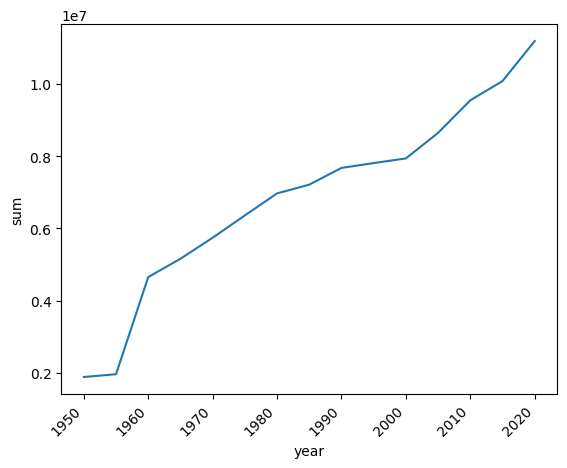

In [21]:
# visualizing enrollment over time in the US
sns.lineplot(x="year", y="sum", data=enrollments_us_total)
plt.xticks(
    rotation=45,       # Set the rotation angle (e.g., 45 degrees)
    ha='right'         # Align the label's right edge to the tick mark
)

In [22]:
# 2008 financial crisis

In [23]:
# aggregating overall global enrollment by region
enrollment_by_year_by_region_df = enrollments_subset_df.groupby(['region', 'year'])['students5_estimated'].agg(['sum']).reset_index()

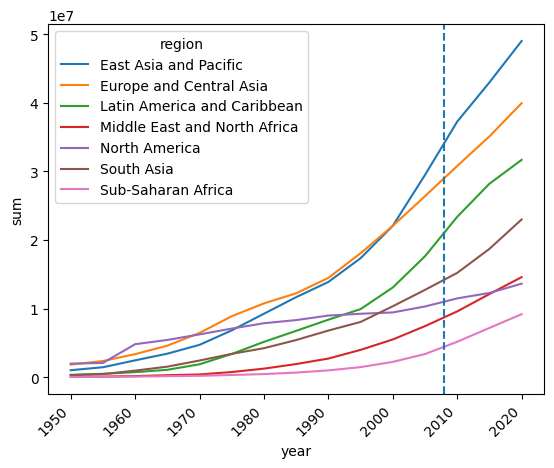

In [24]:
# visualizing overall global enrollment by region
# do not see any notable signal of the financial crisis in this view
sns.lineplot(x="year", y="sum", hue="region", data=enrollment_by_year_by_region_df)
plt.xticks(
    rotation=45,       # Set the rotation angle (e.g., 45 degrees)
    ha='right'         # Align the label's right edge to the tick mark
)
plt.axvline(x=2008, ls='--')

In [25]:
# focusing in on the United States -
# let's look at private school vs. public school enrollment, particularly considering price differentials to attend
us_enrollment_by_year_by_private_df = enrollments_us_df.groupby(['private01', 'year'])['students5_estimated'].agg(['sum']).reset_index()
us_enrollment_by_year_by_private_df['perc_change'] = us_enrollment_by_year_by_private_df.groupby('private01')['sum'].pct_change()

In [26]:
us_enrollment_by_year_by_private_df[us_enrollment_by_year_by_private_df['year'] > 2000]

,private01,year,sum,perc_change
11,0.0,2005.0,6393424.0,0.080576
12,0.0,2010.0,6861953.0,0.073283
13,0.0,2015.0,7180768.0,0.046461
14,0.0,2020.0,7893458.0,0.099250
26,1.0,2005.0,2249919.0,0.114260
27,1.0,2010.0,2681622.0,0.191875
28,1.0,2015.0,2895657.0,0.079815
29,1.0,2020.0,3290588.0,0.136387


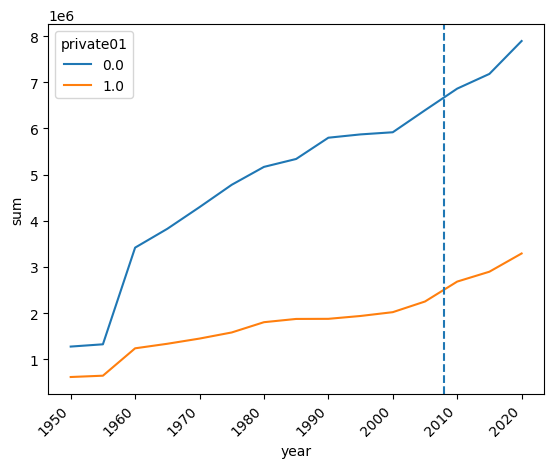

In [27]:
# was there a difference between enrollment in private institutions vs. public before/after 2008?
sns.lineplot(x="year", y="sum", hue="private01", data=us_enrollment_by_year_by_private_df)
plt.xticks(
    rotation=45,       # Set the rotation angle (e.g., 45 degrees)
    ha='right'         # Align the label's right edge to the tick mark
)
plt.axvline(x=2008, ls='--')

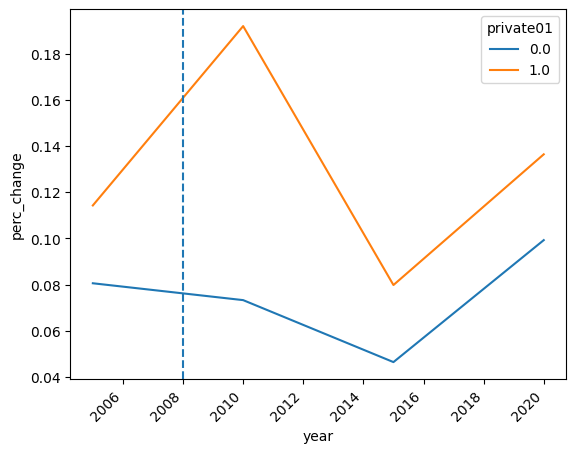

In [28]:
# it appears that there was an influx of students in private schools after 2008 crisis
# however, it appears that there was a slowing in the increase in enrollment in both groups by 2015
sns.lineplot(x="year", y="perc_change", hue="private01", data=us_enrollment_by_year_by_private_df[us_enrollment_by_year_by_private_df['year'] > 2000])
plt.xticks(
    rotation=45,       # Set the rotation angle (e.g., 45 degrees)
    ha='right'         # Align the label's right edge to the tick mark
)
plt.axvline(x=2008, ls='--')

In [29]:
# Investigating GDP relationship to university enrollment. 

In [30]:
gdp_pivot_df = gdp_df.melt(id_vars=['Country Name', 'Country Code'], 
                           value_vars=[x for x in gdp_df if x not in ['Country Name', 'Country Code']],
                           value_name='gdp',
                           var_name='year')

In [31]:
gdp_pivot_df.head(5)

,Country Name,Country Code,year,gdp
0,Africa Eastern and Southern,AFE,1960,1.931311e+10
1,Africa Western and Central,AFW,1960,1.040428e+10
2,Australia,AUS,1960,1.860679e+10
3,Austria,AUT,1960,6.592694e+09
4,Burundi,BDI,1960,1.960000e+08


In [32]:
# cast year to float to enable join
gdp_pivot_df['year'] = gdp_pivot_df['year'].astype(float)

In [33]:
# aggregate enrollment by country prior to joining to GDP data
enrollment_by_country_df = enrollments_df.groupby(['countrycode', 'year'])['students5_estimated'].agg(['sum']).reset_index()
enrollment_by_country_df.rename(columns={'sum': 'students5_estimated'}, inplace=True)

In [34]:
# join GDP data to the enrollments data on Year and  Country
enrollments_w_gdp = pd.merge(enrollment_by_country_df, gdp_pivot_df, left_on=['countrycode','year'],
                                    right_on=['Country Code', 'year'])

In [35]:
# look at 2020 data and run a simple linear model to quickly identify if there is a linear relationship between GDP 
# and enrollment
# Note: Regression expects no autocorrelation of residuals (i.e. time series data), with additional time we could explore
# ARIMA or other time series based modeling approaches
enrollments_w_gdp_2020 = enrollments_w_gdp[enrollments_w_gdp['year'] == 2020]
len(enrollments_w_gdp_2020) # observation count

84

<Axes: xlabel='students5_estimated', ylabel='gdp'>

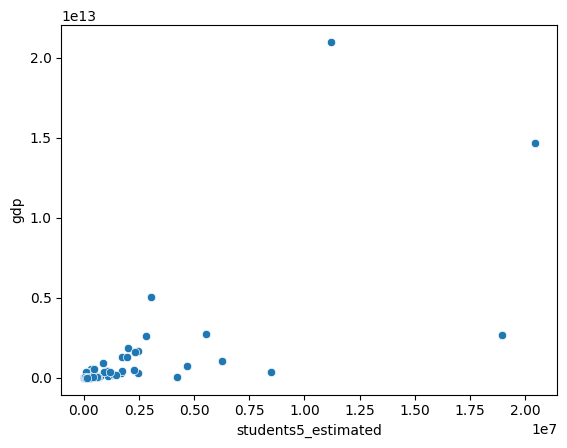

In [36]:
# there is an increase in variance (heteroskedasticity) that will impact the model as GDP & enrollment increase
sns.scatterplot(enrollments_w_gdp_2020, x='students5_estimated', y='gdp')

<Axes: xlabel='students5_estimated', ylabel='gdp'>

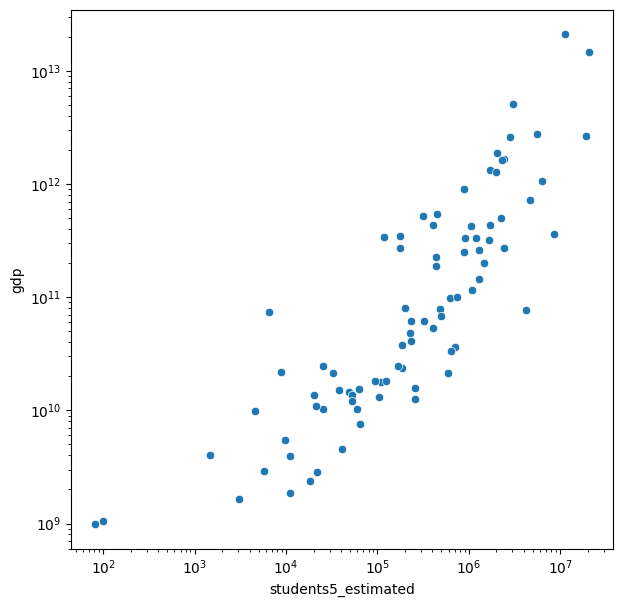

In [37]:
# once we apply a log scale, the heteroskedasticity is reduced
f, ax = plt.subplots(figsize=(7, 7))
ax.set(xscale="log", yscale="log")
sns.scatterplot(enrollments_w_gdp_2020, x='students5_estimated', y='gdp')

In [38]:
# GDP is a statistically significant explanation for the variance in enrollment in 2020
# Intepreting the coefficient, a 1% increase in GDP would be equivalent to ~0.49% increase in college enrollment
model = OLS(np.log(enrollments_w_gdp_2020['students5_estimated']),np.log(enrollments_w_gdp_2020['gdp']), missing='drop').fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     students5_estimated   R-squared (uncentered):                   0.984
Model:                             OLS   Adj. R-squared (uncentered):              0.984
Method:                  Least Squares   F-statistic:                              5037.
Date:                 Sat, 13 Dec 2025   Prob (F-statistic):                    4.49e-76
Time:                         19:09:55   Log-Likelihood:                         -158.52
No. Observations:                   84   AIC:                                      319.0
Df Residuals:                       83   BIC:                                      321.5
Df Model:                            1                                                  
Covariance Type:             nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
gdp            0.4949      0.007     70.971      0.000       0.481       0.509
==============================================================================
Omnibus:                       24.884   Durbin-Watson:                   1.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               39.831
Skew:                          -1.210   Prob(JB):                     2.24e-09
Kurtosis:                       5.350   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""